In [ ]:
from pathlib import Path

import polars as pl
from polars import functions as F


print(f"{Path.cwd() = }")
cwd = Path.cwd()
data_dir: Path = cwd.parent.parent.joinpath("data")

df = pl.read_csv(
    data_dir.joinpath("cv-corpus-24.0-2025-12-05", "en", "train.tsv"),
    separator="\t",
    has_header=True,
    # ignore_errors=True,
    quote_char="",
)
df.head()

In [2]:
existing_files = set(data_dir.joinpath("cv-corpus-24.0-2025-12-05", "en", "clips").glob("*.mp3"))

existing_paths_df = pl.DataFrame({"path": [str(fpath).split("/")[-1] for fpath in existing_files]})

In [3]:
filtered_df = df.join(existing_paths_df, on="path", how="semi")
filtered_df.head()

client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment
str,str,str,str,str,i64,i64,str,str,str,str,str,str
"""c6d3938559e6dcc8be5177abdd15e5…","""common_voice_en_110548.mp3""","""7dd54c7df1e85dca9aa8c5772af205…","""She sat on the floor drinking …",null,3,0,null,null,null,null,"""en""",null
"""c6d3938559e6dcc8be5177abdd15e5…","""common_voice_en_110550.mp3""","""fde2561f28f9798c50faf76ab15530…","""He preferred to sit down and w…",null,2,0,null,null,null,null,"""en""",null
"""c6ee6c579a5e26da6a3235b67cd911…","""common_voice_en_19963420.mp3""","""2aa1c0da6f0564e9be5ee1804c22f6…","""This marked the start of what …",null,2,1,null,null,null,null,"""en""",null
"""c6ee6c579a5e26da6a3235b67cd911…","""common_voice_en_19963423.mp3""","""2aa118c8f1aaa538f9084edbcb493c…","""By that time, they had individ…",null,2,1,null,null,null,null,"""en""",null
"""c6ee6c579a5e26da6a3235b67cd911…","""common_voice_en_19963424.mp3""","""2a9a687224a24a5fe71fd9660de40f…","""Recently, Weymouth College has…",null,2,0,null,null,null,null,"""en""",null


In [4]:
target_client_id = (
    filtered_df
    .group_by("client_id")
    .agg(pl.col("path"))
    .with_columns(num_paths=pl.col("path").list.len())
    .sort("num_paths", descending=True)
    .filter((pl.col("num_paths") >= 100) & (pl.col("num_paths") <= 1_000))
    .head(1)["client_id"].to_list()[0]
)

target_client_id

'468d6a3b83f807ed964c180ed893ac7c39f9ea1860213261ed075ce3f8c1403d77bc8157c3ab2548bfbc7885be878a423b004a77cf28a7289421937952069126'

In [ ]:
target_df = filtered_df.filter(pl.col("client_id") == target_client_id)

files = [
    data_dir.joinpath("cv-corpus-24.0-2025-12-05", "en", "clips", path)
    for path in 
    target_df["path"].to_list()
]

In [7]:
import numpy as np

from resemblyzer import VoiceEncoder, preprocess_wav
from tqdm import tqdm

np.set_printoptions(precision=3, suppress=True)
encoder = VoiceEncoder()

embs = []
for path in tqdm(files, desc="Embedding voice files"):
    wav = preprocess_wav(path)
    emb = encoder.embed_utterance(wav)
    embs.append(emb)


Loaded the voice encoder model on cpu in 0.01 seconds.


Embedding voice files: 100%|██████████| 996/996 [00:29<00:00, 33.83it/s]


In [8]:
from sklearn.metrics.pairwise import cosine_similarity

csims = cosine_similarity(embs)
n_samples = csims.shape[0]
print(f"{n_samples = }")
masked_csims = np.triu(csims, k=1)
print("avg csim =", (2 * masked_csims.sum()) / (n_samples * (n_samples - 1)))  # sum i=1..n_samples formula

n_samples = 996
avg csim = 0.8198533


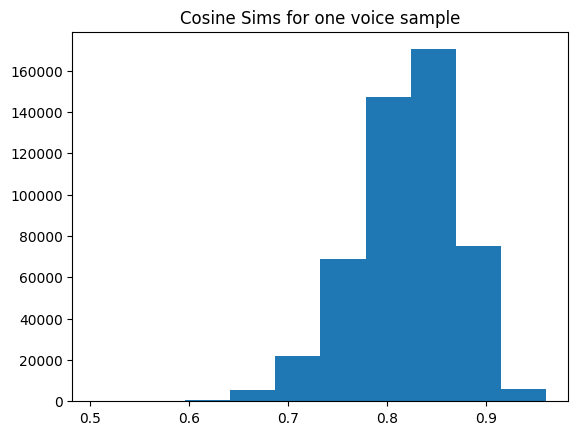

In [9]:
from matplotlib import pyplot as plt

plt.title("Cosine Sims for one voice sample")
plt.hist(masked_csims[masked_csims != 0.])
plt.show()

In [10]:
samples_df = pl.DataFrame({"path": (str(f).split("/")[-1] for f in files), "emb": embs})
samples_df = target_df.join(samples_df, on="path", how="inner")
samples_df = samples_df.select("path", "sentence", "emb")
samples = list(samples_df.iter_rows(named=True))

holdout_sample = None
train_set = []
test_set = []

for d in samples:
    if d["sentence"] == 'Securities are transferred according to instructions provided by parties with access to the system.':
        holdout_sample = d
    elif len(train_set) < 20:
        train_set.append(d)
    else:
        test_set.append(d)

print(f"{holdout_sample = }")
print(f"{len(train_set) = }")
print(f"{len(test_set) = }")

holdout_sample = {'path': 'common_voice_en_23385850.mp3', 'sentence': 'Securities are transferred according to instructions provided by parties with access to the system.', 'emb': [0.1604938954114914, 0.0, 0.16389602422714233, 0.0, 0.0, 0.0022758538834750652, 0.07782657444477081, 0.04377841204404831, 0.06353557109832764, 0.013709460385143757, 0.04920710623264313, 0.011533094570040703, 0.0, 0.0, 0.0, 0.0, 0.10189227759838104, 0.0, 0.038920190185308456, 0.0, 0.022342730313539505, 0.024560682475566864, 0.0, 0.0, 0.0, 0.025445744395256042, 0.0, 0.0021542178001254797, 0.0, 0.0, 0.014172080904245377, 0.035347916185855865, 0.0, 0.06697767972946167, 0.004857515450567007, 0.21268869936466217, 0.08151966333389282, 0.010189973749220371, 0.0, 0.016934510320425034, 0.0, 0.0, 0.12161817401647568, 0.00817449763417244, 0.028910601511597633, 0.0, 0.0028267204761505127, 0.027330094948410988, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.09358067810535431, 0.008142336271703243, 0.062183354049921036, 0.098008

In [11]:
import warnings

holdout_sample["emb"] = np.array(holdout_sample["emb"])

def check_answer(filepath: str) -> float:
    global holdout_sample, encoder

    emb = encoder.embed_utterance(preprocess_wav(filepath)).reshape(1, -1)
    return float(cosine_similarity(np.array(holdout_sample["emb"]).reshape(1, -1), emb).squeeze())

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print("test sim: ", check_answer(Path("~/Documents/test_recording.m4a").expanduser()))

test sim:  0.644104494474035


In [ ]:
# write out challenge files
import pickle

with open("./answer_file.pkl", "wb") as f:
    pickle.dump({
        **holdout_sample,
        "emb": holdout_sample["emb"].tolist(),
    }, f)
